# 12_v5c_3_3_with_dbmf — V5C 3.3 (DBMF 替代 TQQQ)

> 测试: 把 V5C 3.2 中的 TQQQ 5% 替换为 DBMF 5%, 作为长期对冲缓冲

## 三个版本对比

| 标的 | V5C 3.1 | V5C 3.2 | V5C 3.3 |
|---|---|---|---|
| VOO | 15% | 10% | 10% |
| QQQ | 15% | 15% | 15% |
| TQQQ | 0% | **5%** | 0% |
| HQH | 10% | 10% | 10% |
| XLV | 10% | 10% | 10% |
| GLDM | 20% | 20% | 20% |
| BCX | 10% | 10% | 10% |
| **DBMF** | **0%** | **0%** | **5%** ⚡ |
| VGSH | 20% | 20% | 20% |
| 结构 | 50/30/20 | 50/30/20 | **45/35/20** |

## 数据限制

- DBMF: 2019-05 起 → **只有 7 年数据**
- 长史 (23.8Y) 测试只能用 AQRIX 代理
- AQRIX vs DBMF 7Y 相关性 0.252（**不是好代理**）
- 主测试: **7Y 实际数据** (覆盖 2020 COVID + 2022 滞胀)

## 核心问题

1. V5C 3.3 在 2022 滞胀的表现 vs V5C 3.1 / V5C 3.2？
2. V5C 3.3 整体 Sharpe vs V5C 3.1？
3. V5C 3.3 Max DD 是否改善？

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ['VFINX','QQQ','TQQQ','HQH','XLV','VFITX','GLD','GC=F','DBC','PCRIX','DBMF','AQRIX']
raw = yf.download(tickers, start='1999-01-01', auto_adjust=True)['Close']

print('数据起始:')
for t in tickers:
    if t in raw.columns:
        first = raw[t].first_valid_index()
        print(f'  {t:<8}: {first.date() if first else "N/A"}')

[*********************100%***********************]  12 of 12 completed

数据起始:
  VFINX   : 1999-01-04
  QQQ     : 1999-03-10
  TQQQ    : 2010-02-11
  HQH     : 1999-01-04
  XLV     : 1999-01-04
  VFITX   : 1999-01-04
  GLD     : 2004-11-18
  GC=F    : 2000-08-30
  DBC     : 2006-02-06
  PCRIX   : 2002-07-01
  DBMF    : 2019-05-08
  AQRIX   : 2010-09-30


In [2]:
def synthesize(short, long):
    short = short.dropna(); long = long.dropna()
    if len(short) == 0: return long
    overlap = short.index[0]
    if overlap <= long.index[0]: return short
    long_at = long.loc[:overlap].iloc[-1] if not long.loc[:overlap].empty else long.iloc[0]
    scale = short.iloc[0] / long_at
    early = long.loc[:overlap].iloc[:-1] * scale
    return pd.concat([early, short]).sort_index().pipe(lambda s: s[~s.index.duplicated(keep='last')])

data = pd.DataFrame({
    'VOO': raw['VFINX'], 'QQQ': raw['QQQ'], 'TQQQ': raw['TQQQ'],
    'HQH': raw['HQH'], 'XLV': raw['XLV'],
    'VGSH': raw['VFITX'],
    'GLDM': synthesize(raw['GLD'], raw['GC=F']),
    'BCX': synthesize(raw['DBC'], raw['PCRIX']),
    'DBMF': raw['DBMF'],
    'AQRIX': raw['AQRIX'],
})

In [3]:
def simulate_rebalance(returns_df, target_weights, threshold_pp=5.0):
    used = [t for t in target_weights.keys() if t in returns_df.columns]
    sub = returns_df[used].dropna()
    target = np.array([target_weights[t] for t in used]); target = target/target.sum()
    cw = target.copy(); pr=[]; rd=[sub.index[0]]
    for date, dr in sub.iterrows():
        pr.append(np.sum(cw*dr.values))
        nw = cw*(1+dr.values); nw = nw/nw.sum()
        if np.max(np.abs(nw-target))*100 >= threshold_pp:
            cw = target.copy(); rd.append(date)
        else:
            cw = nw
    return pd.Series(pr, index=sub.index), rd

def metrics(rs, dates, name):
    cum = (1+rs).cumprod()
    n_y = len(rs)/252
    cagr = cum.iloc[-1]**(1/n_y) - 1
    vol = rs.std()*np.sqrt(252)
    sharpe = (cagr-0.04)/vol
    downside = rs[rs<0]
    sortino = (cagr-0.04)/(downside.std()*np.sqrt(252))
    rm = cum.expanding().max()
    dd = (cum/rm - 1)
    return {'Name':name,'CAGR':cagr,'Vol':vol,'Sharpe':sharpe,'Sortino':sortino,
            'Max DD':dd.min(),'Max DD Date':dd.idxmin(),
            'Calmar':cagr/abs(dd.min()),'Rebalances':len(dates)-1,'Years':n_y}

def show_compare(metric_list):
    cols = ['CAGR','Vol','Sharpe','Sortino','Max DD','Calmar']
    print(f"{'Metric':<10}", end='')
    for m in metric_list: print(f"  {m['Name']:<22}", end='')
    print()
    print('-'*100)
    for col in cols:
        fmt = '{:.2%}' if col not in ['Sharpe','Sortino','Calmar'] else '{:.3f}'
        line = f'{col:<10}'
        for m in metric_list:
            line += f'  {fmt.format(m[col]):<22}'
        print(line)
    print(f"{'Rebalances':<10}", end='')
    for m in metric_list: print(f"  {str(m['Rebalances']):<22}", end='')
    print()

In [4]:
# ============================================================
# 测试 1 (核心): 7Y - 实际 DBMF 数据
# ============================================================
print('=' * 100)
print('测试 1 (核心): 7Y - V5C 3.1 vs V5C 3.2 (TQQQ) vs V5C 3.3 (DBMF)')
print('=' * 100)

data_7y = data[['VOO','QQQ','TQQQ','HQH','XLV','VGSH','GLDM','BCX','DBMF']].dropna()
ret_7y = data_7y.pct_change().dropna()
print(f'窗口: {data_7y.index[0].date()} → {data_7y.index[-1].date()} ({len(data_7y)/252:.1f} 年)')

V5C_3_1 = {'VOO':0.15,'QQQ':0.15,'HQH':0.10,'XLV':0.10,'GLDM':0.20,'BCX':0.10,'VGSH':0.20}
V5C_3_2 = {'VOO':0.10,'QQQ':0.15,'TQQQ':0.05,'HQH':0.10,'XLV':0.10,'GLDM':0.20,'BCX':0.10,'VGSH':0.20}
V5C_3_3 = {'VOO':0.10,'QQQ':0.15,'HQH':0.10,'XLV':0.10,'GLDM':0.20,'BCX':0.10,'DBMF':0.05,'VGSH':0.20}

for name, w in [('V5C 3.1', V5C_3_1), ('V5C 3.2', V5C_3_2), ('V5C 3.3', V5C_3_3)]:
    print(f'  {name} 权重和: {sum(w.values()):.2f}')

r_31, d_31 = simulate_rebalance(ret_7y, V5C_3_1)
r_32, d_32 = simulate_rebalance(ret_7y, V5C_3_2)
r_33, d_33 = simulate_rebalance(ret_7y, V5C_3_3)

show_compare([
    metrics(r_31, d_31, '3.1 (基准)'),
    metrics(r_32, d_32, '3.2 (TQQQ 5%)'),
    metrics(r_33, d_33, '3.3 (DBMF 5%)'),
])

print('\n关键时期表现 (7Y 窗口):')
events_7y = {
    '2020 COVID':         ('2020-02-19', '2020-04-30'),
    '2020 流动性极端':     ('2020-03-09', '2020-03-23'),
    '2020-2021 反弹':      ('2020-04-30', '2021-12-31'),
    '2022 Bear (全年)':    ('2022-01-01', '2022-12-31'),
    '2022 滞胀核心':        ('2022-01-01', '2022-09-30'),
    '2023-2024 AI 牛':    ('2023-01-01', '2024-12-31'),
    '2025 Q1 关税':         ('2025-01-01', '2025-04-30'),
}
print(f"{'时期':<22} {'3.1':>10} {'3.2':>10} {'3.3':>10} {'3.3-3.1':>10}")
for n, (s, e) in events_7y.items():
    a = (1 + r_31.loc[s:e]).prod() - 1
    b = (1 + r_32.loc[s:e]).prod() - 1
    c = (1 + r_33.loc[s:e]).prod() - 1
    print(f'{n:<22} {a:>+9.2%}  {b:>+9.2%}  {c:>+9.2%}  {c-a:>+9.2%}')

测试 1 (核心): 7Y - V5C 3.1 vs V5C 3.2 (TQQQ) vs V5C 3.3 (DBMF)
窗口: 2019-05-08 → 2026-05-05 (7.0 年)
  V5C 3.1 权重和: 1.00
  V5C 3.2 权重和: 1.00
  V5C 3.3 权重和: 1.00
Metric      3.1 (基准)                3.2 (TQQQ 5%)           3.3 (DBMF 5%)         
----------------------------------------------------------------------------------------------------
CAGR        14.71%                  16.97%                  13.99%                
Vol         11.55%                  13.99%                  10.73%                
Sharpe      0.927                   0.927                   0.930                 
Sortino     1.167                   1.172                   1.164                 
Max DD      -17.83%                 -21.26%                 -16.60%               
Calmar      0.825                   0.798                   0.842                 
Rebalances  7                       7                       6                     

关键时期表现 (7Y 窗口):
时期                            3.1        3.2        3.3    3.3

In [5]:
# ============================================================
# 测试 2: 16Y - 用 AQRIX 代理 DBMF (有效性存疑, 仅供参考)
# ============================================================
print('=' * 100)
print('测试 2: 16Y - AQRIX 作 DBMF 代理 (仅供参考, 代理相关性 0.252)')
print('=' * 100)

data_16y = data[['VOO','QQQ','HQH','XLV','VGSH','GLDM','BCX','AQRIX']].dropna()
ret_16y = data_16y.pct_change().dropna()
print(f'窗口: {data_16y.index[0].date()} → {data_16y.index[-1].date()} ({len(data_16y)/252:.1f} 年)')

V5C_3_3_proxy = {'VOO':0.10,'QQQ':0.15,'HQH':0.10,'XLV':0.10,
                  'GLDM':0.20,'BCX':0.10,'AQRIX':0.05,'VGSH':0.20}

r_31_16, d_31_16 = simulate_rebalance(ret_16y, V5C_3_1)
r_33_16, d_33_16 = simulate_rebalance(ret_16y, V5C_3_3_proxy)

show_compare([
    metrics(r_31_16, d_31_16, '3.1 (基准)'),
    metrics(r_33_16, d_33_16, '3.3-proxy (AQRIX)'),
])

print('\n关键时期 (16Y, AQRIX 代理):')
events_16y = {
    '2018-Q4 跌势':       ('2018-10-01', '2018-12-31'),
    '2020 COVID':         ('2020-02-19', '2020-04-30'),
    '2022 Bear':          ('2022-01-01', '2022-12-31'),
    '2023-2024 AI 牛':    ('2023-01-01', '2024-12-31'),
    '2025 Q1 关税':        ('2025-01-01', '2025-04-30'),
}
print(f"{'时期':<22} {'3.1':>10} {'3.3-proxy':>12} {'Δ':>10}")
for n, (s, e) in events_16y.items():
    a = (1 + r_31_16.loc[s:e]).prod() - 1
    b = (1 + r_33_16.loc[s:e]).prod() - 1
    print(f'{n:<22} {a:>+9.2%}  {b:>+9.2%}    {b-a:>+9.2%}')

测试 2: 16Y - AQRIX 作 DBMF 代理 (仅供参考, 代理相关性 0.252)
窗口: 2010-09-30 → 2026-05-05 (15.6 年)
Metric      3.1 (基准)                3.3-proxy (AQRIX)     
----------------------------------------------------------------------------------------------------
CAGR        11.22%                  10.58%                
Vol         10.18%                  9.86%                 
Sharpe      0.709                   0.668                 
Sortino     0.916                   0.863                 
Max DD      -18.00%                 -17.43%               
Calmar      0.623                   0.607                 
Rebalances  11                      9                     

关键时期 (16Y, AQRIX 代理):
时期                            3.1    3.3-proxy          Δ
2018-Q4 跌势                -7.91%     -7.64%       +0.26%
2020 COVID                -3.84%     -3.87%       -0.03%
2022 Bear                 -9.41%    -10.09%       -0.68%
2023-2024 AI 牛           +32.22%    +29.39%       -2.83%
2025 Q1 关税                +4.90% 

In [6]:
# ============================================================
# DBMF 单标的特征 (7Y 窗口)
# ============================================================
print('=' * 60)
print('DBMF 单标的特征 (vs 其他对冲资产, 7Y 窗口)')
print('=' * 60)

print(f'{"资产":<10} {"CAGR":>9} {"Vol":>8} {"Sharpe":>9} {"MaxDD":>9} {"vsVOO":>9}')
print('-'*60)
for label in ['VOO','GLDM','BCX','DBMF','VGSH']:
    s = ret_7y[label]
    cum = (1+s).cumprod()
    cagr = cum.iloc[-1]**(252/len(s))-1
    vol = s.std()*np.sqrt(252)
    sharpe = (cagr-0.04)/vol
    rm = cum.expanding().max()
    dd = (cum/rm - 1).min()
    cv = s.corr(ret_7y['VOO'])
    print(f'{label:<10} {cagr:>+8.2%}  {vol:>6.2%}  {sharpe:>+.3f}   {dd:>+7.2%}  {cv:>+.3f}')

# DBMF 在 2022 单年表现 (关键测试)
dbmf_2022 = (1 + ret_7y['DBMF'].loc['2022-01-01':'2022-12-31']).prod() - 1
voo_2022 = (1 + ret_7y['VOO'].loc['2022-01-01':'2022-12-31']).prod() - 1
qqq_2022 = (1 + ret_7y['QQQ'].loc['2022-01-01':'2022-12-31']).prod() - 1
gld_2022 = (1 + ret_7y['GLDM'].loc['2022-01-01':'2022-12-31']).prod() - 1
bcx_2022 = (1 + ret_7y['BCX'].loc['2022-01-01':'2022-12-31']).prod() - 1

print('\n2022 滞胀年单标的:')
print(f'  VOO  : {voo_2022:>+7.2%}')
print(f'  QQQ  : {qqq_2022:>+7.2%}')
print(f'  DBMF : {dbmf_2022:>+7.2%}  ⭐ (关键)')
print(f'  GLDM : {gld_2022:>+7.2%}')
print(f'  BCX  : {bcx_2022:>+7.2%}')

DBMF 单标的特征 (vs 其他对冲资产, 7Y 窗口)
资产              CAGR      Vol    Sharpe     MaxDD     vsVOO
------------------------------------------------------------
VOO         +15.81%  20.00%  +0.591   -33.83%  +1.000
GLDM        +19.48%  17.62%  +0.879   -22.00%  +0.118
BCX         +12.79%  19.18%  +0.458   -35.15%  +0.318
DBMF         +9.37%  12.46%  +0.431   -20.39%  +0.186
VGSH         +1.54%   5.18%  -0.474   -15.48%  -0.076

2022 滞胀年单标的:
  VOO  : -18.24%
  QQQ  : -32.58%
  DBMF : +21.60%  ⭐ (关键)
  GLDM :  -0.77%
  BCX  : +19.34%


/var/folders/n1/hmrxbc1j7q1gb6jd1gsspzp80000gn/T/ipykernel_3147/2292299261.py:24: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEOGRAPH-51C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n1/hmrxbc1j7q1gb6jd1gsspzp80000gn/T/ipykernel_3147/2292299261.py:24: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n1/hmrxbc1j7q1gb6jd1gsspzp80000gn/T/ipykernel_3147/2292299261.py:24: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n1/hmrxbc1j7q1gb6jd1gsspzp80000gn/T/ipykernel_3147/2292299261.py:24: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n1/hmrxbc1j7q1gb6jd1gsspzp80000gn/T/ipykernel_3147/2292299261.py:24: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n1/hmrxbc1j7

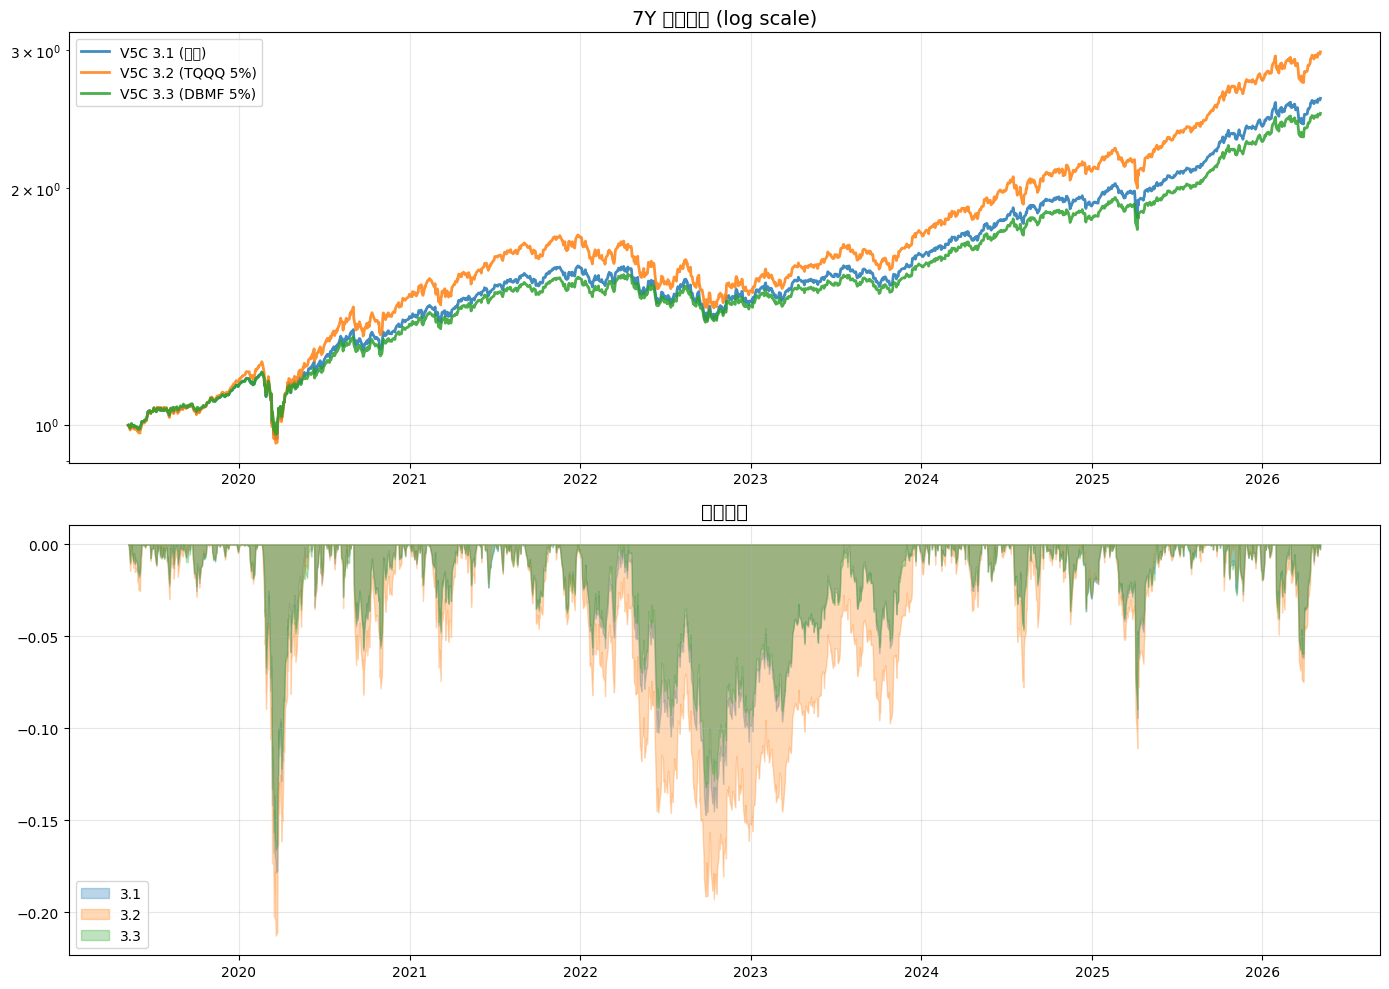

In [7]:
# ============================================================
# 净值 + 回撤 (7Y 窗口)
# ============================================================
cum_31 = (1 + r_31).cumprod()
cum_32 = (1 + r_32).cumprod()
cum_33 = (1 + r_33).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes[0].plot(cum_31, label='V5C 3.1 (基准)', linewidth=2, alpha=0.85)
axes[0].plot(cum_32, label='V5C 3.2 (TQQQ 5%)', linewidth=2, alpha=0.85)
axes[0].plot(cum_33, label='V5C 3.3 (DBMF 5%)', linewidth=2, alpha=0.85)
axes[0].set_title('7Y 净值对比 (log scale)', fontsize=14)
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(alpha=0.3)

for cum, label, color in [(cum_31, '3.1', 'C0'), (cum_32, '3.2', 'C1'), (cum_33, '3.3', 'C2')]:
    rm = cum.expanding().max()
    dd = (cum / rm) - 1
    axes[1].fill_between(dd.index, dd.values, 0, alpha=0.3, color=color, label=label)
axes[1].set_title('回撤对比', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 解读思路

### 三组对比的核心问题

1. **V5C 3.3 vs V5C 3.1**：DBMF 5% 是否提供有效对冲？
   - 期望：Max DD 改善（特别在 2022）
   - 期望：Sharpe 大致持平或略降（DBMF 7Y Sharpe 仅 0.423）

2. **V5C 3.3 vs V5C 3.2**：DBMF 是否比 TQQQ 更适合『长期持有』？
   - V5C 3.2 在 7Y 因 AI 牛市受益（CAGR 高）
   - V5C 3.3 应当 Max DD 更浅, Vol 更低

3. **2022 滞胀**：DBMF 这个单标的的关键测试时刻
   - DBMF 2022 +20% 是它存在的核心理由
   - 5% 的 DBMF 应当让 V5C 3.3 在 2022 比 V5C 3.1/3.2 表现更好

## 决策标准

**采纳 V5C 3.3** 如果：
- 7Y Sharpe ≥ V5C 3.1 - 0.05 (轻微下降可接受)
- 2022 Bear 表现明显优于 V5C 3.1 (≥ +2pp)
- Max DD 改善 ≥ 1pp
- **核心**: 心理可承受 (DBMF 不会让你想清仓)

## 最重要的判断

**这次修订不是基于 Sharpe**, 是基于『心理-策略匹配』原则。
即使 V5C 3.3 Sharpe 比 V5C 3.1 略低 0.02-0.05, 仍然采纳，
因为它**符合 V5C 设计哲学（真分散+心理可承载）**。